<a href="https://colab.research.google.com/github/VladimirSharaP/Audio_Processing/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Установка библиотек

In [ ]:
!sudo apt install -y fluidsynth
!pip install --upgrade pyfluidsynth
!pip install --upgrade music21
!add-apt-repository ppa:mscore-ubuntu/mscore-stable -y
!apt-get update
!apt-get install musescore
!apt-get install xvfb
!pip install pretty_midi

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fluid-soundfont-gm libevdev2 libfluidsynth3 libgudev-1.0-0 libinput-bin
  libinput10 libinstpatch-1.0-2 libmd4c0 libmtdev1 libqt5core5a libqt5dbus5
  libqt5gui5 libqt5network5 libqt5svg5 libqt5widgets5 libwacom-bin
  libwacom-common libwacom9 libxcb-icccm4 libxcb-image0 libxcb-keysyms1
  libxcb-render-util0 libxcb-util1 libxcb-xinerama0 libxcb-xinput0 libxcb-xkb1
  libxkbcommon-x11-0 qsynth qt5-gtk-platformtheme qttranslations5-l10n
  timgm6mb-soundfont
Suggested packages:
  fluid-soundfont-gs qt5-image-formats-plugins qtwayland5 jackd
The following NEW packages will be installed:
  fluid-soundfont-gm fluidsynth libevdev2 libfluidsynth3 libgudev-1.0-0
  libinput-bin libinput10 libinstpatch-1.0-2 libmd4c0 libmtdev1 libqt5core5a
  libqt5dbus5 libqt5gui5 libqt5network5 libqt5svg5 libqt5widgets5 libwacom-bin
  libwacom-common libwacom9 libx

In [ ]:
from music21 import *

# настраиваем окружение в соответствии с документацией
us = environment.UserSettings()
us['musescoreDirectPNGPath'] = '/usr/bin/mscore'
us['directoryScratch'] = '/tmp'

In [ ]:
import collections
import datetime
import fluidsynth
import glob
import numpy as np
import pathlib
import pandas as pd
import pretty_midi
import seaborn as sns
import tensorflow as tf

from IPython import display
from matplotlib import pyplot as plt
from typing import Dict, List, Optional, Sequence, Tuple

In [ ]:
# Импортируем библиотеки
import tensorflow
import os
import numpy as np
import pandas as pd
from collections import Counter
import random
import IPython
from IPython.display import Image, Audio
import music21
from music21 import *
import fluidsynth
# импортируем загруженную библиотеку для работы с MIDI
import pretty_midi

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
import keras.backend as K
from keras.optimizers import Adamax

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline

import sys
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")
seed = 42
tensorflow.random.set_seed(seed)
np.random.seed(seed)

# Sampling rate for audio playback
_SAMPLING_RATE = 16000

Загрузка данных

In [ ]:
!wget https://storage.yandexcloud.net/academy.ai/classical-music-midi.zip

# Разархивируем датасета во временную папку 'dataset'
!unzip -qo "classical-music-midi" -d ./dataset

!dir ./dataset

--2024-11-09 15:36:45--  https://storage.yandexcloud.net/academy.ai/classical-music-midi.zip
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2751606 (2.6M) [application/x-zip-compressed]
Saving to: ‘classical-music-midi.zip’

classical-music-mid 100%[===================>]   2.62M  2.39MB/s    in 1.1s    

2024-11-09 15:36:47 (2.39 MB/s) - ‘classical-music-midi.zip’ saved [2751606/2751606]

Albeniz    Borodin	Christmas  Granados  Mendelssohn  Rachmaninoff	Sinding
Bach	   Brahms	Clementi   Grieg     Moszkowski   Ravel		Tchaikovsky
Balakirev  Burgmueller	Debussy    Haydn     Mozart	  Schubert
Beethoven  Chopin	Godowsky   Liszt     Mussorgsky   Schumann


Предобработка данных

In [ ]:
#Собираем все произведения в одну переменную

import glob
filenames = glob.glob(str('dataset/Chopin/*.mid*'))
print('Колличество файлов:', len(filenames))

Колличество файлов: 48


In [ ]:
sample_file = filenames[1]
print(sample_file)

dataset/Chopin/chpn_op27_2.mid


In [ ]:
#Фрагмент из датасета

pm = pretty_midi.PrettyMIDI(sample_file)

def display_audio(pm: pretty_midi.PrettyMIDI, seconds=30):
  waveform = pm.fluidsynth(fs=_SAMPLING_RATE)
  # Take a sample of the generated waveform to mitigate kernel resets
  waveform_short = waveform[:seconds*_SAMPLING_RATE]
  return display.Audio(waveform_short, rate=_SAMPLING_RATE)

In [ ]:
display_audio(pm)

In [ ]:
# функция преобразования MIDI в DataFrame, содержащий ноты и их расширенные параметры

def midi_to_notes(midi_file: str) -> pd.DataFrame:
  # чтение MIDI
  pm = pretty_midi.PrettyMIDI(midi_file)
  # извлечение первого инструмента
  instrument = pm.instruments[0]
  # объявляем список для хранения нот
  notes = collections.defaultdict(list)
  # сортируем ноты по времени начала ноты
  sorted_notes = sorted(instrument.notes, key=lambda note: note.start)
  # переменная для расчета шага, хранит предущее значение start
  prev_start = sorted_notes[0].start # начало первой ноты

  for note in sorted_notes:
    # начало ноты
    start = note.start
    # конец ноты
    end = note.end
    notes['pitch'].append(note.pitch)          # имя ноты
    notes['start'].append(start)               # начало ноты
    notes['end'].append(end)                   # конец ноты
    notes['step'].append(start - prev_start)   # шаг
    notes['duration'].append(end - start)      # длительность ноты
    # запоминаем значение предыдущего старта
    prev_start = start

  return pd.DataFrame({name: np.array(value) for name, value in notes.items()}) # функция возвращает значение DataFrame библиотеки pandas

raw_notes = midi_to_notes(sample_file)
raw_notes.head()

,pitch,start,end,step,duration
0,77,3.771365,5.608045,0.000000,1.836680
1,75,5.608045,6.226602,1.836680,0.618557
2,73,6.226602,7.180770,0.618557,0.954168
3,65,7.180770,7.518346,0.954168,0.337576
4,68,7.518346,9.962321,0.337576,2.443975


Визуализация некоторых параметров

In [ ]:
#Распределение нот по времени
def plot_piano_roll(notes: pd.DataFrame, count: Optional[int] = None):
  if count:
    title = f'First {count} notes'
  else:
    title = f'Whole track'
    count = len(notes['pitch'])
  plt.figure(figsize=(20, 4))
  plot_pitch = np.stack([notes['pitch'], notes['pitch']], axis=0)
  plot_start_stop = np.stack([notes['start'], notes['end']], axis=0)
  plt.plot(
      plot_start_stop[:, :count], plot_pitch[:, :count], color="b", marker=".")
  plt.xlabel('Time [s]')
  plt.ylabel('Pitch')
  _ = plt.title(title)

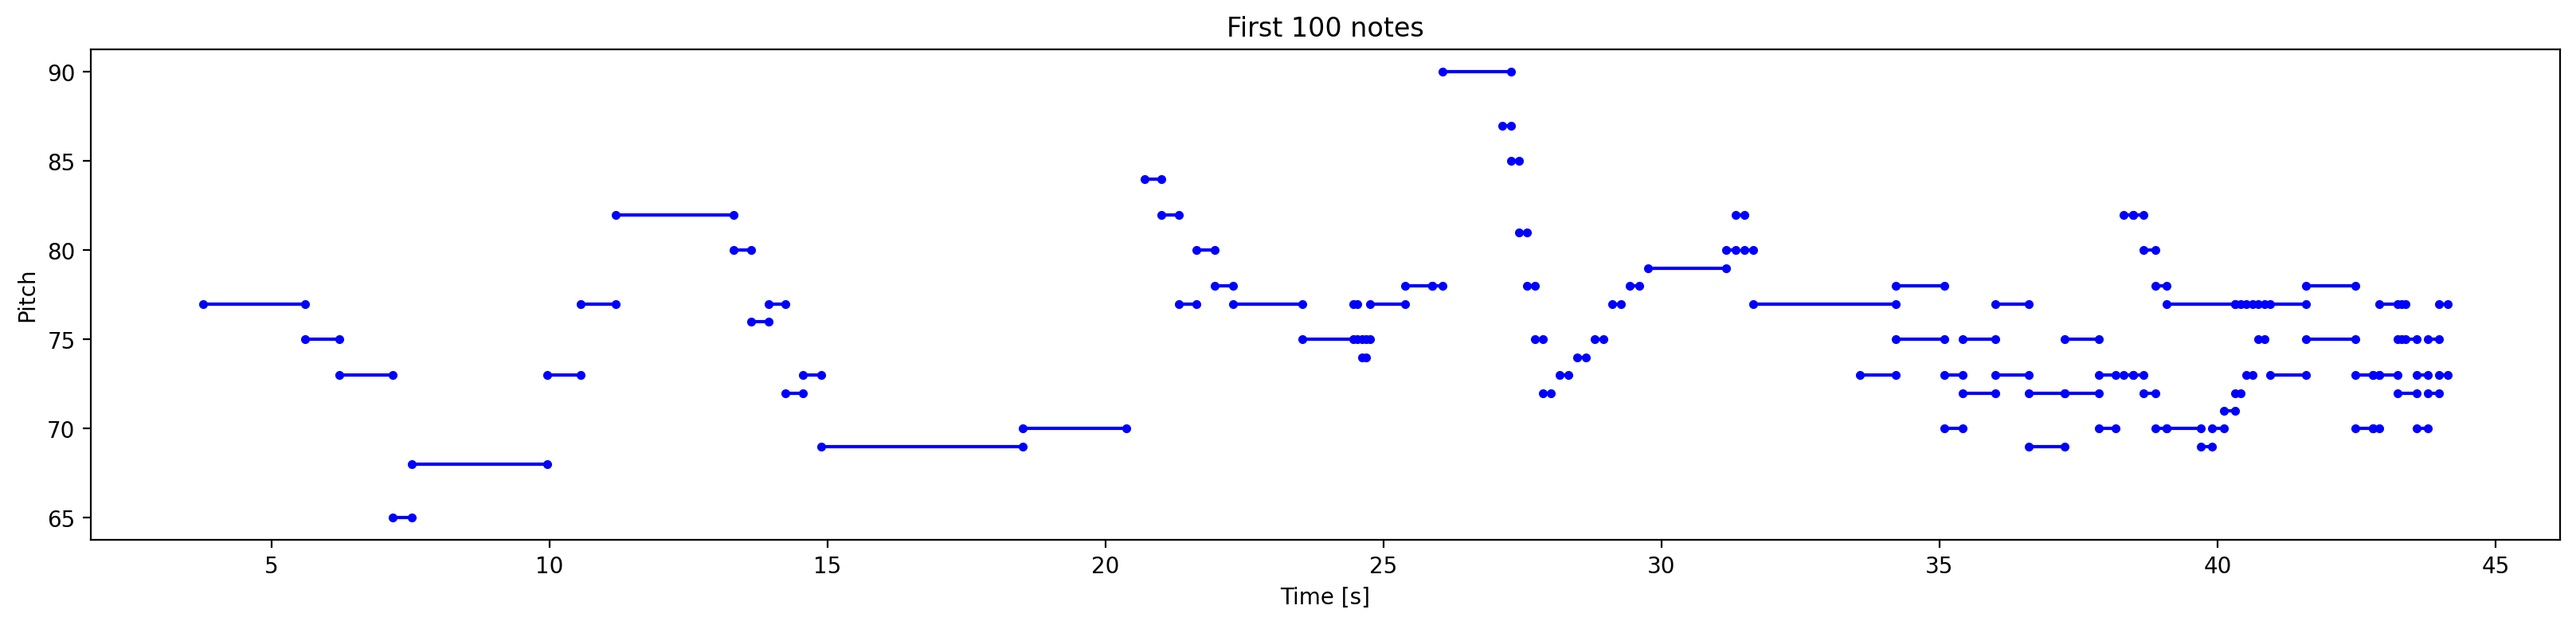

In [ ]:
plot_piano_roll(raw_notes, count=100)

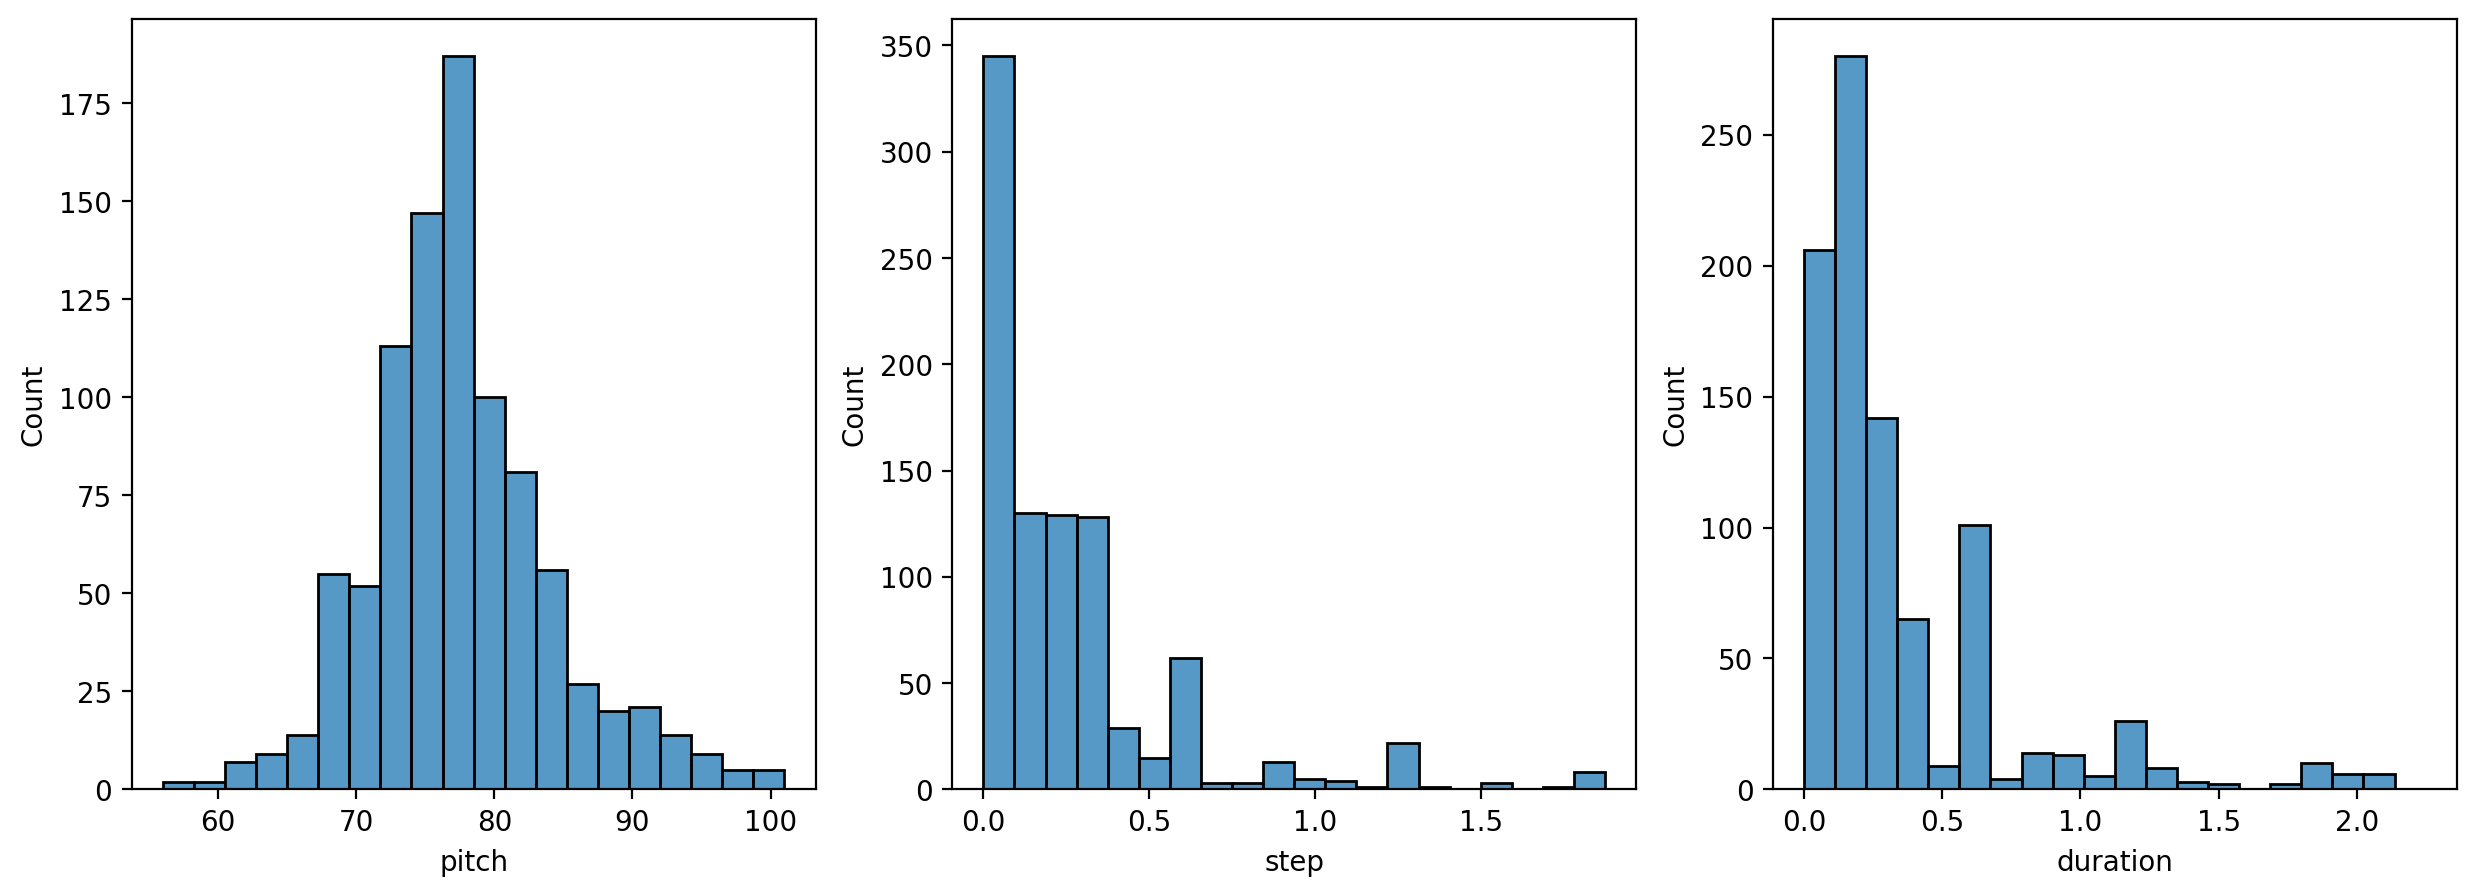

In [ ]:
#Распределение параметров по колличеству
def plot_distributions(notes: pd.DataFrame, drop_percentile=2.5):
  plt.figure(figsize=[15, 5])
  plt.subplot(1, 3, 1)
  sns.histplot(notes, x="pitch", bins=20)

  plt.subplot(1, 3, 2)
  max_step = np.percentile(notes['step'], 100 - drop_percentile)
  sns.histplot(notes, x="step", bins=np.linspace(0, max_step, 21))

  plt.subplot(1, 3, 3)
  max_duration = np.percentile(notes['duration'], 100 - drop_percentile)
  sns.histplot(notes, x="duration", bins=np.linspace(0, max_duration, 21))

plot_distributions(raw_notes)

In [ ]:
#Пример MIDI-файла из списка нот

def notes_to_midi(
  notes: pd.DataFrame,
  out_file: str,
  instrument_name: str,
  velocity: int = 100,
) -> pretty_midi.PrettyMIDI:

  pm = pretty_midi.PrettyMIDI()
  instrument = pretty_midi.Instrument(
      program=pretty_midi.instrument_name_to_program(
          instrument_name))

  prev_start = 0
  for i, note in notes.iterrows():
    start = float(prev_start + note['step'])
    end = float(start + note['duration'])
    note = pretty_midi.Note(
        velocity=velocity,
        pitch=int(note['pitch']),
        start=start,
        end=end,
    )
    instrument.notes.append(note)
    prev_start = start

  pm.instruments.append(instrument)
  pm.write(out_file)
  return pm

example_file = 'example.midi'
example_pm = notes_to_midi(
    raw_notes, out_file=example_file, instrument_name=instrument_name)

display_audio(example_pm)

Формирование обучающих данных

In [ ]:
#Получаем все ноты из выбранных файлов
num_files = len(filenames)
all_notes = []
for f in filenames[:num_files]:
  notes = midi_to_notes(f)
  all_notes.append(notes)

all_notes = pd.concat(all_notes)

n_notes = len(all_notes)
print('Всего нот во всех midi-файлах всего датасета:', n_notes)

Всего нот во всех midi-файлах всего датасета: 40305


In [ ]:
#Формируем датасет с интересующими нас колонками
key_order = ['pitch', 'step', 'duration']
train_notes = np.stack([all_notes[key] for key in key_order], axis=1)

notes_ds = tf.data.Dataset.from_tensor_slices(train_notes)
notes_ds.element_spec

TensorSpec(shape=(3,), dtype=tf.float64, name=None)

In [ ]:
#создание объектов и меток
def create_sequences(
    dataset: tf.data.Dataset,
    seq_length: int,
    vocab_size = 128,
) -> tf.data.Dataset:
  """Returns TF Dataset of sequence and label examples."""
  seq_length = seq_length+1


  windows = dataset.window(seq_length, shift=1, stride=1,
                              drop_remainder=True)


  flatten = lambda x: x.batch(seq_length, drop_remainder=True)
  sequences = windows.flat_map(flatten)


  def scale_pitch(x):
    x = x/[vocab_size,1.0,1.0]
    return x


  def split_labels(sequences):
    inputs = sequences[:-1]
    labels_dense = sequences[-1]
    labels = {key:labels_dense[i] for i,key in enumerate(key_order)}

    return scale_pitch(inputs), labels

  return sequences.map(split_labels, num_parallel_calls=tf.data.AUTOTUNE)

In [ ]:
seq_length = 25
vocab_size = 128
seq_ds = create_sequences(notes_ds, seq_length, vocab_size)
seq_ds.element_spec

(TensorSpec(shape=(25, 3), dtype=tf.float64, name=None),
 {'pitch': TensorSpec(shape=(), dtype=tf.float64, name=None),
  'step': TensorSpec(shape=(), dtype=tf.float64, name=None),
  'duration': TensorSpec(shape=(), dtype=tf.float64, name=None)})

In [ ]:
for seq, target in seq_ds.take(1):
  print('форма пакета:', seq.shape)
  print('первые 10 эллементов пакета:', seq[0: 10])
  print()
  print(target)

форма пакета: (25, 3)
первые 10 эллементов пакета: tf.Tensor(
[[0.5625     0.         0.1357465 ]
 [0.5390625  0.1357465  0.1357465 ]
 [0.5078125  0.1357465  0.1357465 ]
 [0.484375   0.1357465  0.1357465 ]
 [0.46875    0.1357465  0.13430025]
 [0.5078125  0.13430025 0.13430025]
 [0.6015625  0.13430025 0.13430025]
 [0.578125   0.13430025 0.13430025]
 [0.5625     0.13430025 0.13430025]
 [0.5390625  0.13430025 0.13430025]], shape=(10, 3), dtype=float64)

{'pitch': <tf.Tensor: shape=(), dtype=float64, numpy=69.0>, 'step': <tf.Tensor: shape=(), dtype=float64, numpy=0.13590649999999993>, 'duration': <tf.Tensor: shape=(), dtype=float64, numpy=0.13590649999999993>}


Инициализация модели

In [ ]:
batch_size = 64
buffer_size = n_notes - seq_length
train_ds = (seq_ds
            .shuffle(buffer_size)
            .batch(batch_size, drop_remainder=True)
            .cache()
            .prefetch(tf.data.experimental.AUTOTUNE))

train_ds.element_spec

(TensorSpec(shape=(64, 25, 3), dtype=tf.float64, name=None),
 {'pitch': TensorSpec(shape=(64,), dtype=tf.float64, name=None),
  'step': TensorSpec(shape=(64,), dtype=tf.float64, name=None),
  'duration': TensorSpec(shape=(64,), dtype=tf.float64, name=None)})

In [ ]:
#Пользовательская функция потерь, основанная на среднеквадратической ошибке
def mse_with_positive_pressure(y_true: tf.Tensor, y_pred: tf.Tensor):
  mse = (y_true - y_pred) ** 2
  positive_pressure = 10 * tf.maximum(-y_pred, 0.0)
  return tf.reduce_mean(mse + positive_pressure)

#Создание модели. Модель будет иметь три выхода, по одному для каждой переменной ноты.
input_shape = (seq_length, 3)
learning_rate = 0.005

inputs = tf.keras.Input(input_shape)
x = tf.keras.layers.LSTM(256)(inputs)

outputs = {
  'pitch': tf.keras.layers.Dense(128, name='pitch')(x),
  'step': tf.keras.layers.Dense(1, name='step')(x),
  'duration': tf.keras.layers.Dense(1, name='duration')(x),
}

model = tf.keras.Model(inputs, outputs)

loss = {
      'pitch': tf.keras.losses.SparseCategoricalCrossentropy(
          from_logits=True),
      'step': mse_with_positive_pressure,
      'duration': mse_with_positive_pressure,
}

optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

model.compile(loss=loss, optimizer=optimizer)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 25, 3)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_2 (LSTM)             │ (None, 256)            │        266,240 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ duration (Dense)          │ (None, 1)              │            257 │ lstm_2[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pitch (Dense)             │ (None, 128)            │         32,896 │ lstm_2[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ step (Dense)              │ (None, 1)              │            257 │ lstm_2[0][0]           │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 299,650 (1.14 MB)

 Trainable params: 299,650 (1.14 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    loss=loss,
    loss_weights={
        'pitch': 0.05,
        'step': 1.0,
        'duration':1.0,
    },
    optimizer=optimizer,
)

Обучение модели

In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath='./training_checkpoints/ckpt_{epoch}.weights.h5',
        save_weights_only=True),
    tf.keras.callbacks.EarlyStopping(
        monitor='loss',
        patience=5,
        verbose=1,
        restore_best_weights=True),
]

epochs = 50

history = model.fit(
    train_ds,
    epochs=epochs,
    callbacks=callbacks,
)

Epoch 1/50
629/629 ━━━━━━━━━━━━━━━━━━━━ 85s 130ms/step - loss: 0.6543
Epoch 2/50
629/629 ━━━━━━━━━━━━━━━━━━━━ 88s 140ms/step - loss: 0.5938
Epoch 3/50
629/629 ━━━━━━━━━━━━━━━━━━━━ 75s 120ms/step - loss: 0.5737
Epoch 4/50
629/629 ━━━━━━━━━━━━━━━━━━━━ 72s 114ms/step - loss: 0.5585
Epoch 5/50
629/629 ━━━━━━━━━━━━━━━━━━━━ 90s 127ms/step - loss: 0.5533
Epoch 6/50
629/629 ━━━━━━━━━━━━━━━━━━━━ 72s 111ms/step - loss: 0.5430
Epoch 7/50
629/629 ━━━━━━━━━━━━━━━━━━━━ 69s 109ms/step - loss: 0.5389
Epoch 8/50
629/629 ━━━━━━━━━━━━━━━━━━━━ 84s 113ms/step - loss: 0.5288
Epoch 9/50
629/629 ━━━━━━━━━━━━━━━━━━━━ 74s 117ms/step - loss: 0.5337
Epoch 10/50
629/629 ━━━━━━━━━━━━━━━━━━━━ 73s 116ms/step - loss: 0.5291
Epoch 11/50
629/629 ━━━━━━━━━━━━━━━━━━━━ 72s 115ms/step - loss: 0.5220
Epoch 12/50
629/629 ━━━━━━━━━━━━━━━━━━━━ 118s 173ms/step - loss: 0.5166
Epoch 13/50
629/629 ━━━━━━━━━━━━━━━━━━━━ 69s 109ms/step - loss: 0.5198
Epoch 14/50
629/629 ━━━━━━━━━━━━━━━━━━━━ 69s 109ms/step - loss: 0.5190
Epoch 15/50
62

Оценка результатов

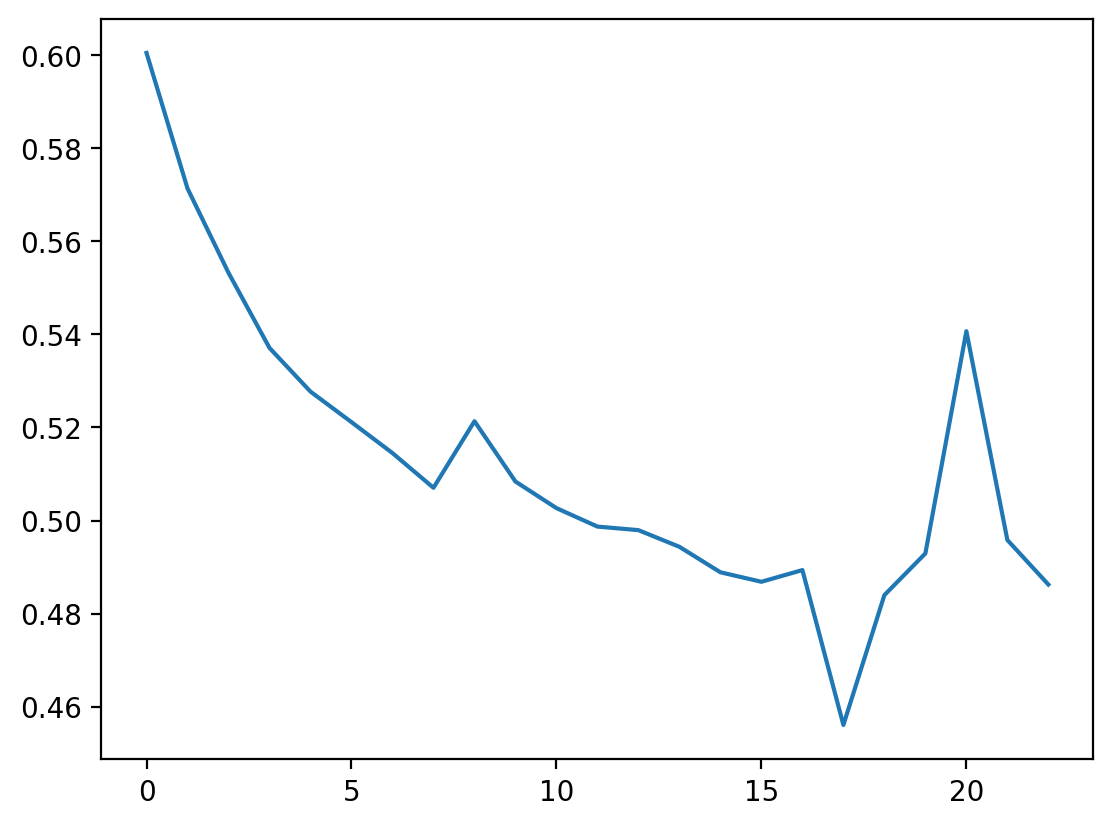

In [ ]:
plt.plot(history.epoch, history.history['loss'], label='total loss')
plt.show()

In [ ]:
#Функция генерации следующей ноты
def predict_next_note(
    notes: np.ndarray,
    keras_model: tf.keras.Model,
    temperature: float = 1.0) -> int:
  """Generates a note IDs using a trained sequence model."""

  assert temperature > 0

  inputs = tf.expand_dims(notes, 0)

  predictions = model.predict(inputs)
  pitch_logits = predictions['pitch']
  step = predictions['step']
  duration = predictions['duration']

  pitch_logits *= temperature
  pitch = tf.random.categorical(pitch_logits, num_samples=1)
  pitch = tf.squeeze(pitch, axis=-1)
  duration = tf.squeeze(duration, axis=-1)
  step = tf.squeeze(step, axis=-1)

  step = tf.maximum(0, step)
  duration = tf.maximum(0, duration)

  return int(pitch), float(step), float(duration)

In [ ]:
#Собираем все произведения в одну переменную

filenames = glob.glob(str('dataset/Mozart/*.mid*'))
print('Колличество файлов', len(filenames))

#Получаем ноты выбранных произведений

all_notes = []
for f in filenames:
  notes = midi_to_notes(f)
  all_notes.append(notes)

all_notes = pd.concat(all_notes)

n_notes = len(all_notes)
print('Всего нот во всех midi-файлах всего датасета:', n_notes)

Колличество файлов 21
Всего нот во всех midi-файлах всего датасета: 38545


In [ ]:
#Температура модели влияет на генерацию. Более низкие температуры соответствуют более точному
#предсказанию, а более высокие температуры приводят к более случайной генерации.

temperature = 0.3

#Колличество предсказанных нот
num_predictions = 120

#Выбираем начальную последовательность нот
key_order = ['pitch', 'step', 'duration']
sample_notes = np.stack([all_notes[key] for key in key_order], axis=1)
#np.stack([raw_notes[key] for key in key_order], axis=1)

#Высота звука нормализуется аналогично обучающим последовательностям
input_notes = (
    sample_notes[:seq_length] / np.array([vocab_size, 1, 1]))

generated_notes = []
prev_start = 0
for _ in range(num_predictions):
  pitch, step, duration = predict_next_note(input_notes, model, temperature)
  start = prev_start + step
  end = start + duration
  input_note = (pitch, step, duration)
  generated_notes.append((*input_note, start, end))
  input_notes = np.delete(input_notes, 0, axis=0)
  input_notes = np.append(input_notes, np.expand_dims(input_note, 0), axis=0)
  prev_start = start

generated_notes = pd.DataFrame(
    generated_notes, columns=(*key_order, 'start', 'end'))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━

In [ ]:
generated_notes.head(10)

,pitch,step,duration,start,end
0,77,0.968221,0.965199,0.968221,1.933420
1,95,0.641076,0.747046,1.609297,2.356343
2,100,0.626906,0.613404,2.236203,2.849607
3,94,0.625605,0.611656,2.861808,3.473464
4,86,0.625003,0.609815,3.486811,4.096626
5,99,0.627637,0.615215,4.114449,4.729664
6,98,0.626464,0.612953,4.740912,5.353866
7,96,0.623056,0.602481,5.363968,5.966449
8,92,0.625816,0.611062,5.989784,6.600846
9,79,0.624593,0.612611,6.614377,7.226988


In [ ]:
#Сгенерированный аудио

out_file = 'output.mid'
out_pm = notes_to_midi(
    generated_notes, out_file=out_file, instrument_name=instrument_name)
display_audio(out_pm)

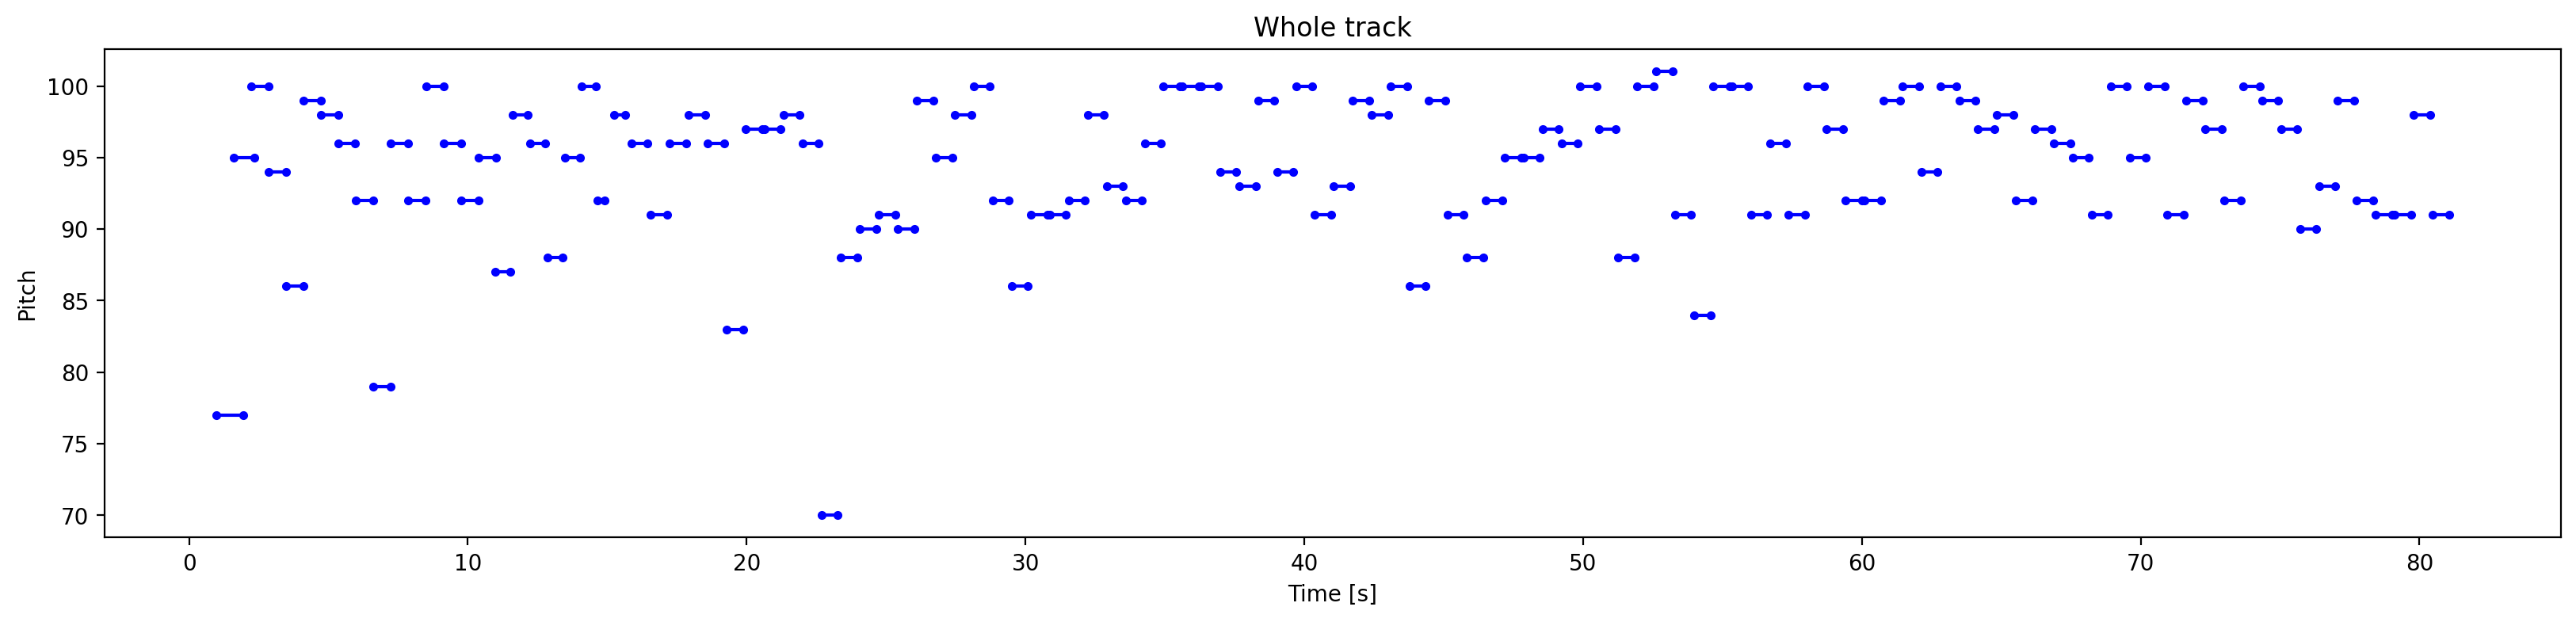

In [ ]:
plot_piano_roll(generated_notes)

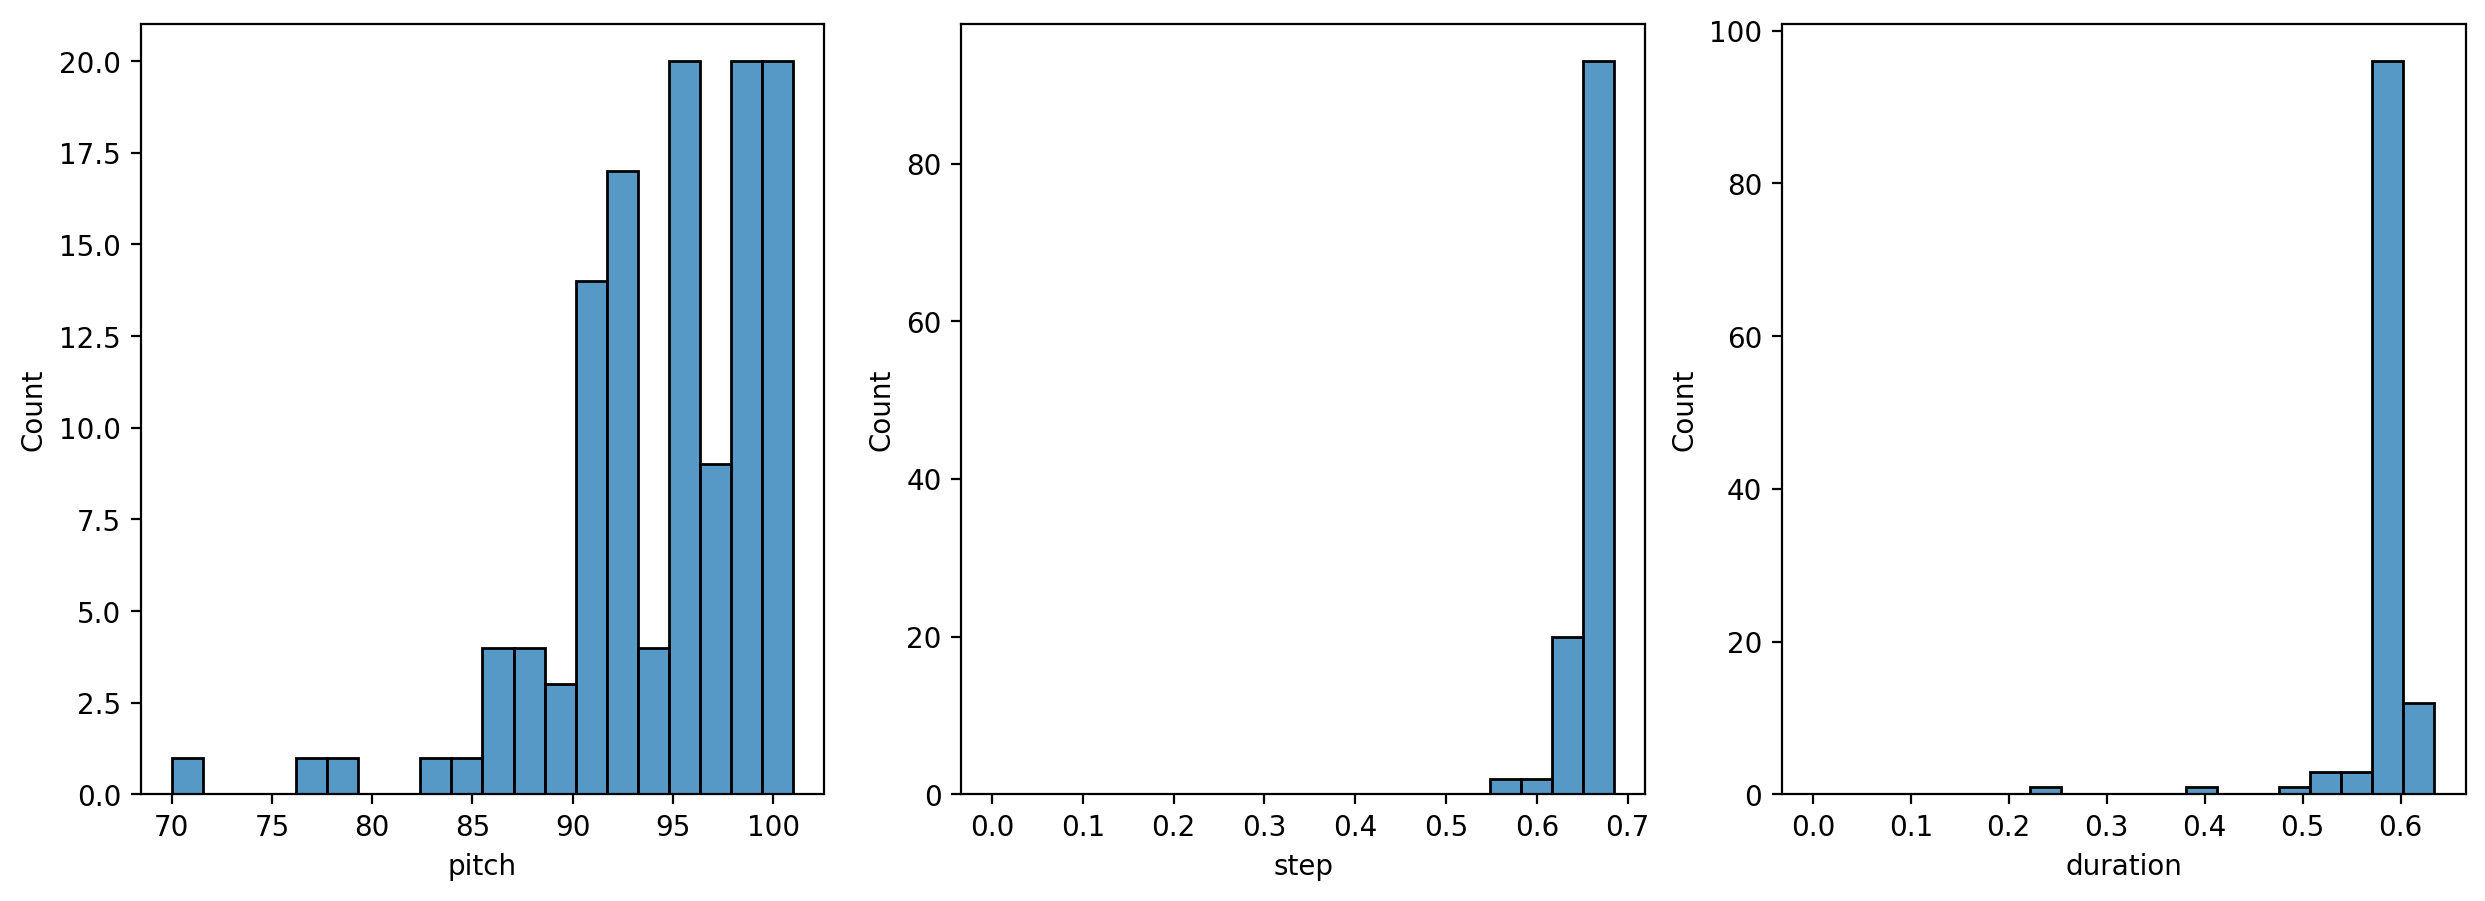

In [ ]:
plot_distributions(generated_notes)